# 106 --- Live Option Chain (In-Notebook)

A fully self-contained, live-updating option chain that renders **inside the notebook**.
No Streamlit, no external browser app. Uses `ipywidgets` for interactive controls
and `IPython.display` for live-updating styled tables.

**Features:**
- Dropdown expiration selector
- Full option chain with Greeks (IV, Delta, Gamma, Theta) computed via the Rust Black-Scholes calculator
- ITM/ATM color coding
- One-click and auto-refresh modes
- IV smile plot and term structure visualization

**Install dependencies:**
```
pip install thetadatadx[pandas] ipywidgets
```

In [1]:
from thetadatadx import Credentials, Config, ThetaDataDx, all_greeks, implied_volatility
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

creds = Credentials.from_file("creds.txt")
tdx = ThetaDataDx(creds, Config.production())
print("Connected!")

Connected!


## Choose Ticker and Expiration

In [2]:
ticker = "SPY"

# Fetch spot price
spot_snap = tdx.stock_snapshot_ohlc([ticker])
spot = spot_snap["close"][0] if spot_snap else 0.0
print(f"{ticker} spot: ${spot:.2f}")

# Fetch expirations and build readable labels
expirations = tdx.option_list_expirations(ticker)
_today = __import__("time").strftime("%Y%m%d")
expirations = [e for e in expirations if e.replace("-", "") > _today]
today = datetime.now()

exp_labels = []
for exp_str in expirations[:20]:
    exp_dt = datetime.strptime(exp_str.replace("-", ""), "%Y%m%d")
    dte = (exp_dt - today).days
    exp_labels.append(f"{exp_str}  ({exp_dt.strftime('%b %d')} --- {dte}d)")

print(f"{ticker}: {len(expirations)} expirations available")

# Dropdown for expiration
exp_dropdown = widgets.Dropdown(
    options=list(zip(exp_labels, expirations[:20])),
    description="Expiration:",
    style={"description_width": "initial"},
)
display(exp_dropdown)

SPY spot: $701.54


SPY: 33 expirations available


Dropdown(description='Expiration:', options=(('2026-04-20  (Apr 20 --- 2d)', '2026-04-20'), ('2026-04-21  (Apr…

## Build the Option Chain

In [3]:
RISK_FREE = 0.05
DIV_YIELD = 0.013


def build_option_chain(ticker, expiration, spot_price, num_strikes=20):
    """Fetch quotes for calls and puts, compute Greeks, return DataFrame."""

    exp_dt = datetime.strptime(expiration.replace("-", ""), "%Y%m%d")
    dte = (exp_dt - datetime.now()).days
    tte = max(dte / 365.0, 1 / 365.0)

    # Get all strikes
    all_strikes = tdx.option_list_strikes(ticker, expiration)
    if not all_strikes:
        return pd.DataFrame()

    # ThetaData strikes are stored as integer strings (strike * 1000)
    strike_pairs = [(s, float(s)) for s in all_strikes]

    # Filter to N strikes around ATM
    atm_idx = min(range(len(strike_pairs)), key=lambda i: abs(strike_pairs[i][1] - spot_price))
    half = num_strikes // 2
    start = max(0, atm_idx - half)
    end = min(len(strike_pairs), atm_idx + half + 1)
    selected = strike_pairs[start:end]

    rows = []
    for strike_str, strike_val in selected:
        row = {"strike": strike_val}

        for right, prefix in [("C", "call_"), ("P", "put_")]:
            

            # Quote (bid/ask)
            try:
                quote = tdx.option_snapshot_quote(ticker, expiration, strike_str, right)
                if quote:
                    bid = quote["bid"][0]
                    ask = quote["ask"][0]
                    mid = (bid + ask) / 2
                else:
                    bid = ask = mid = np.nan
            except Exception:
                bid = ask = mid = np.nan

            row[f"{prefix}bid"] = bid
            row[f"{prefix}ask"] = ask

            # Last trade
            try:
                trade = tdx.option_snapshot_trade(ticker, expiration, strike_str, right)
                row[f"{prefix}last"] = trade["price"][0] if trade else np.nan
                row[f"{prefix}volume"] = trade.get("size", [0])[0] if trade else 0
            except Exception:
                row[f"{prefix}last"] = np.nan
                row[f"{prefix}volume"] = 0

            # Open interest
            try:
                oi_data = tdx.option_snapshot_open_interest(ticker, expiration, strike_str, right)
                if oi_data:
                    oi_val = oi_data.get("open_interest", [0])[0]
                    if isinstance(oi_val, dict):
                        oi_val = oi_val.get("value", 0)
                    row[f"{prefix}oi"] = int(oi_val) if oi_val else 0
                else:
                    row[f"{prefix}oi"] = 0
            except Exception:
                row[f"{prefix}oi"] = 0

            # Greeks via Rust Black-Scholes
            if pd.notna(mid) and mid > 0.01:
                try:
                    g = all_greeks(
                        spot=spot_price,
                        strike=strike_val,
                        rate=RISK_FREE,
                        div_yield=DIV_YIELD,
                        tte=tte,
                        option_price=mid,
                        right=right,
                    )
                    if g["iv_error"] < 0.05:
                        row[f"{prefix}iv"] = g["iv"]
                        row[f"{prefix}delta"] = g["delta"]
                        row[f"{prefix}gamma"] = g["gamma"]
                        row[f"{prefix}theta"] = g["theta"]
                    else:
                        for k in ("iv", "delta", "gamma", "theta"):
                            row[f"{prefix}{k}"] = np.nan
                except Exception:
                    for k in ("iv", "delta", "gamma", "theta"):
                        row[f"{prefix}{k}"] = np.nan
            else:
                for k in ("iv", "delta", "gamma", "theta"):
                    row[f"{prefix}{k}"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


def style_chain(df, spot_price):
    """Apply option-chain styling: ITM highlighting, ATM gold, formatted numbers."""

    # Column order: Calls | Strike | Puts
    call_cols = [
        "call_iv", "call_delta", "call_gamma", "call_theta",
        "call_bid", "call_ask", "call_last", "call_volume", "call_oi",
    ]
    put_cols = [
        "put_bid", "put_ask", "put_last", "put_volume", "put_oi",
        "put_iv", "put_delta", "put_gamma", "put_theta",
    ]
    display_cols = [c for c in call_cols if c in df.columns]
    display_cols.append("strike")
    display_cols.extend([c for c in put_cols if c in df.columns])

    styled_df = df[display_cols].copy()

    # Rename for cleaner headers
    rename = {}
    for c in styled_df.columns:
        parts = c.split("_", 1)
        if len(parts) == 2 and parts[0] in ("call", "put"):
            rename[c] = f"{parts[0][0].upper()}_{parts[1].upper()}"
        else:
            rename[c] = c.upper()
    styled_df.columns = [rename.get(c, c) for c in styled_df.columns]

    # ATM strike
    atm_strike = df.loc[(df["strike"] - spot_price).abs().idxmin(), "strike"]

    def highlight_itm(row):
        styles = [""] * len(row)
        if "STRIKE" not in row.index:
            return styles
        strike = row["STRIKE"]
        strike_pos = list(row.index).index("STRIKE")

        # ITM calls: strike < spot
        if strike < spot_price:
            for i in range(strike_pos):
                styles[i] = "background-color: rgba(76, 175, 80, 0.15)"
        # ITM puts: strike > spot
        if strike > spot_price:
            for i in range(strike_pos + 1, len(row)):
                styles[i] = "background-color: rgba(76, 175, 80, 0.15)"
        # ATM
        if strike == atm_strike:
            styles[strike_pos] = "background-color: rgba(255, 215, 0, 0.35); font-weight: bold"
        return styles

    # Format dict
    fmt = {}
    for c in styled_df.columns:
        if "IV" in c:
            fmt[c] = lambda x: f"{x*100:.1f}%" if pd.notna(x) else ""
        elif "DELTA" in c or "GAMMA" in c or "THETA" in c:
            fmt[c] = lambda x: f"{x:.4f}" if pd.notna(x) else ""
        elif "VOLUME" in c or "OI" in c:
            fmt[c] = lambda x: f"{int(x):,}" if pd.notna(x) and x != 0 else ""
        elif c == "STRIKE":
            fmt[c] = lambda x: f"${x:.1f}" if pd.notna(x) else ""
        else:
            fmt[c] = lambda x: f"{x:.2f}" if pd.notna(x) else ""

    return styled_df.style.apply(highlight_itm, axis=1).format(fmt)


print("build_option_chain() and style_chain() defined.")

build_option_chain() and style_chain() defined.


In [4]:
chain = build_option_chain(ticker, exp_dropdown.value, spot)
exp_dt = datetime.strptime(exp_dropdown.value.replace("-", ""), "%Y%m%d")
dte = (exp_dt - datetime.now()).days

display(HTML(
    f"<h3>{ticker} Option Chain &mdash; {exp_dropdown.value} "
    f"({exp_dt.strftime('%b %d, %Y')}, {dte} DTE) &mdash; "
    f"Spot ${spot:.2f}</h3>"
))
display(style_chain(chain, spot))

,C_IV,C_DELTA,C_GAMMA,C_THETA,C_BID,C_ASK,C_LAST,C_VOLUME,C_OI,STRIKE,P_BID,P_ASK,P_LAST,P_VOLUME,P_OI,P_IV,P_DELTA,P_GAMMA,P_THETA
0,0.0%,0.0000,0.0000,0.0000,104.70,108.39,59.89,1,2,$595.0,0.00,0.01,0.01,20,413,,,,
1,0.0%,0.0000,0.0000,0.0000,72.72,76.33,,,,$627.0,0.01,0.02,0.01,2,155,52.5%,-0.0018,0.0002,-0.0387
2,32.0%,0.9960,0.0007,-0.1134,42.53,42.85,42.67,1,171,$659.0,0.04,0.05,0.05,1,919,35.0%,-0.0074,0.0011,-0.0922
3,19.8%,0.8541,0.0223,-0.6468,11.30,11.61,11.55,1,"1,968",$691.0,0.79,0.81,0.80,1,"1,369",20.0%,-0.1483,0.0223,-0.5899
4,,,,,0.00,0.01,0.01,1,665,$755.0,51.79,55.49,57.65,1,,52.8%,-0.9680,0.0026,-0.4144
5,,,,,0.00,0.01,,,,$915.0,211.88,215.49,,,,160.7%,-0.9850,0.0005,-0.6887
6,0.0%,0.0000,0.0000,0.0000,189.66,193.35,,,,$510.0,0.00,0.01,0.30,112,112,,,,
7,0.0%,0.0000,0.0000,0.0000,93.71,97.40,,,,$606.0,0.00,0.01,0.02,4,"4,863",,,,
8,0.0%,0.0000,0.0000,0.0000,61.74,65.33,58.70,1,1,$638.0,0.02,0.03,0.07,1,235,47.7%,-0.0033,0.0004,-0.0617
9,27.8%,0.9878,0.0022,-0.1798,31.58,31.89,31.83,1,"1,401",$670.0,0.09,0.10,0.09,1,"4,628",29.6%,-0.0170,0.0027,-0.1606


## Live Auto-Refresh

Use the **Refresh** button for a one-shot update, or toggle **Auto-refresh**
and run the next cell to poll every 5 seconds. Interrupt the kernel to stop.

In [5]:
output = widgets.Output()
refresh_btn = widgets.Button(description="Refresh", button_style="info", icon="refresh")
auto_toggle = widgets.ToggleButton(value=False, description="Auto-refresh (5s)", icon="repeat")
strikes_slider = widgets.IntSlider(value=20, min=5, max=50, step=5, description="Strikes:")
controls = widgets.HBox([refresh_btn, auto_toggle, strikes_slider])


def refresh(_=None):
    with output:
        clear_output(wait=True)

        # Re-fetch spot
        snap = tdx.stock_snapshot_ohlc([ticker])
        current_spot = snap["close"][0] if snap else spot

        chain = build_option_chain(
            ticker, exp_dropdown.value, current_spot,
            num_strikes=strikes_slider.value,
        )

        if chain.empty:
            print("No data returned.")
            return

        exp_dt = datetime.strptime(exp_dropdown.value.replace("-", ""), "%Y%m%d")
        dte = (exp_dt - datetime.now()).days
        ts = time.strftime("%H:%M:%S")

        display(HTML(
            f"<div style='display:flex; justify-content:space-between; align-items:baseline;'>"
            f"<span style='color:#4FC3F7; font-weight:bold; font-size:14px;'>CALLS</span>"
            f"<span style='font-size:13px;'>{ticker} &mdash; {exp_dropdown.value} "
            f"({dte} DTE) &mdash; Spot ${current_spot:.2f} &mdash; {ts}</span>"
            f"<span style='color:#FF8A65; font-weight:bold; font-size:14px;'>PUTS</span>"
            f"</div>"
        ))
        display(style_chain(chain, current_spot))


refresh_btn.on_click(refresh)
display(controls, output)
refresh()

Output()

In [6]:
# Run this cell to start auto-refresh. Interrupt the kernel (stop button) to stop.
while auto_toggle.value:
    refresh()
    time.sleep(5)

## IV Smile Visualization

Plot the implied volatility smile for calls and puts across strikes
for the currently selected expiration.

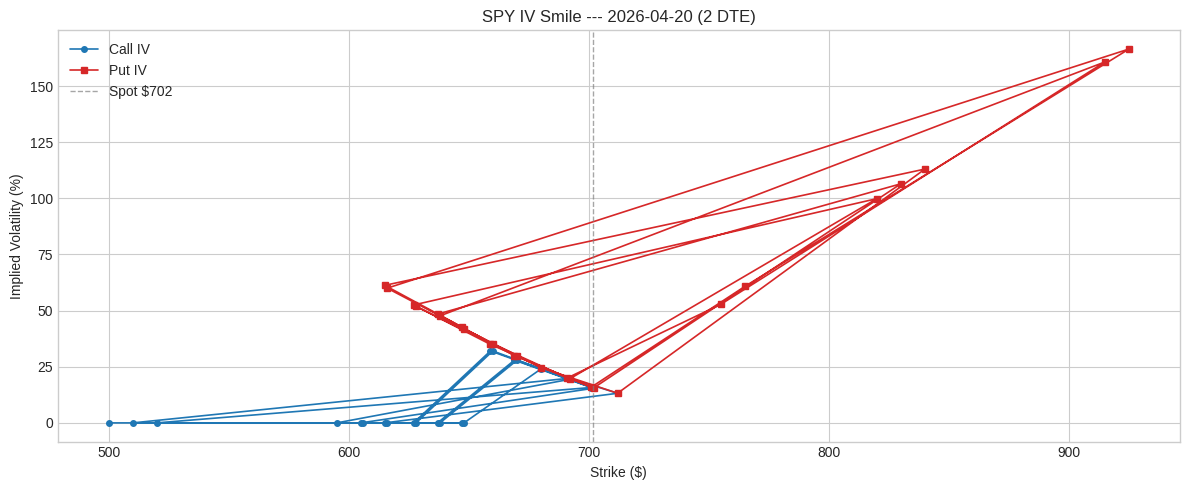

In [7]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

chain = build_option_chain(ticker, exp_dropdown.value, spot, num_strikes=30)

fig, ax = plt.subplots(figsize=(12, 5))

valid_call = chain.dropna(subset=["call_iv"])
valid_put = chain.dropna(subset=["put_iv"])

if len(valid_call) > 0:
    ax.plot(
        valid_call["strike"], valid_call["call_iv"] * 100,
        "o-", color="#1f77b4", markersize=4, linewidth=1.2, label="Call IV",
    )
if len(valid_put) > 0:
    ax.plot(
        valid_put["strike"], valid_put["put_iv"] * 100,
        "s-", color="#d62728", markersize=4, linewidth=1.2, label="Put IV",
    )

ax.axvline(x=spot, color="gray", linestyle="--", linewidth=1, alpha=0.7, label=f"Spot ${spot:.0f}")
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Implied Volatility (%)")

exp_dt = datetime.strptime(exp_dropdown.value.replace("-", ""), "%Y%m%d")
dte = (exp_dt - datetime.now()).days
ax.set_title(f"{ticker} IV Smile --- {exp_dropdown.value} ({dte} DTE)")
ax.legend()
plt.tight_layout()
plt.show()

## Multi-Expiration Term Structure

Fetch the ATM implied volatility for each of the nearest expirations
to visualize how IV varies across the term structure.

  2026-04-20 (  2d): Call IV 15.4%


  2026-04-21 (  3d): Call IV 15.3%


  2026-04-22 (  4d): Call IV 15.2%


  2026-04-23 (  5d): Call IV 15.2%


  2026-04-24 (  6d): Call IV 15.6%


  2026-04-27 (  9d): Call IV 14.5%


  2026-04-28 ( 10d): Call IV 14.6%


  2026-04-29 ( 11d): Call IV 15.4%


  2026-04-30 ( 12d): Call IV 15.9%


  2026-05-01 ( 13d): Call IV 16.2%


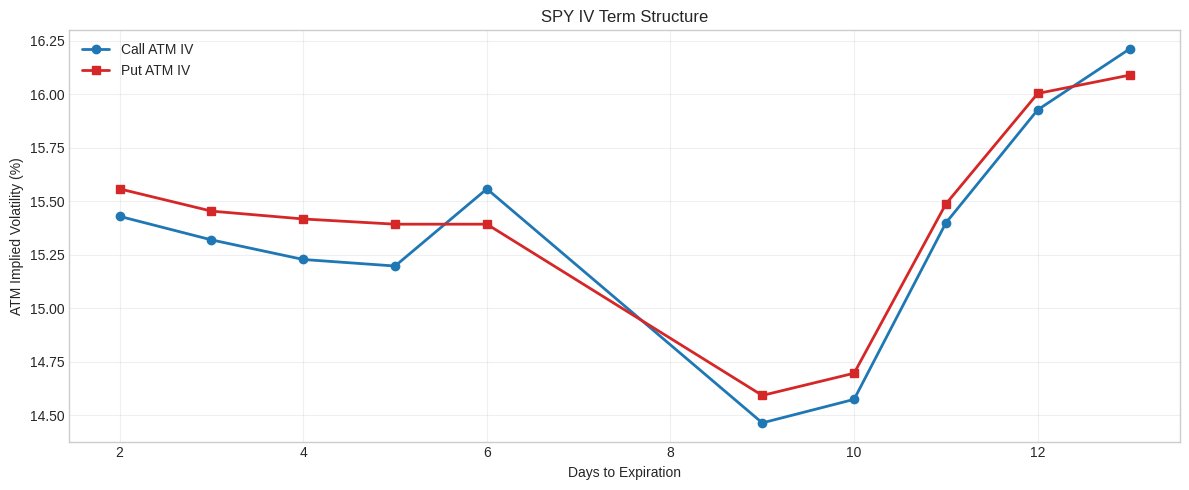

In [8]:
atm_ivs = []
for exp_str in expirations[:10]:
    try:
        ch = build_option_chain(ticker, exp_str, spot, num_strikes=3)
        if ch.empty or "call_iv" not in ch.columns:
            continue

        # Pick the row closest to ATM
        atm_row = ch.loc[(ch["strike"] - spot).abs().idxmin()]
        call_iv = atm_row.get("call_iv", np.nan)
        put_iv = atm_row.get("put_iv", np.nan)

        if pd.notna(call_iv) and call_iv > 0:
            exp_dt = datetime.strptime(exp_str.replace("-", ""), "%Y%m%d")
            dte = (exp_dt - datetime.now()).days
            atm_ivs.append({
                "Expiration": exp_str,
                "DTE": dte,
                "Call ATM IV": call_iv,
                "Put ATM IV": put_iv if pd.notna(put_iv) else np.nan,
            })
            print(f"  {exp_str} ({dte:>3}d): Call IV {call_iv*100:.1f}%")
    except Exception as exc:
        print(f"  {exp_str}: skipped ({exc})")
        continue

if atm_ivs:
    term = pd.DataFrame(atm_ivs)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(term["DTE"], term["Call ATM IV"] * 100, "o-", color="#1f77b4", linewidth=2, label="Call ATM IV")
    if term["Put ATM IV"].notna().any():
        ax.plot(term["DTE"], term["Put ATM IV"] * 100, "s-", color="#d62728", linewidth=2, label="Put ATM IV")
    ax.set_xlabel("Days to Expiration")
    ax.set_ylabel("ATM Implied Volatility (%)")
    ax.set_title(f"{ticker} IV Term Structure")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No ATM IV data collected.")

---

**Full dashboard:** For a richer real-time GUI with tabbed expirations, open-interest charts,
and configurable display, run the Streamlit app:

```
streamlit run ../tools/live-chain/app.py
```

**Previous:** [105 --- Real-Time Streaming with FPSS](105_realtime_streaming.ipynb)  
**Back to start:** [101 --- Getting Started](101_getting_started.ipynb)